# Moon-Math -- a quantitative teardown of the Stock-to-Flow model
### Real BTC-USD daily tape * spurious regression tests * first-diff OLS * OOS R2 * synthetic controls

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Spurious_regression%3F: Busted](https://img.shields.io/badge/Spurious_regression%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We apply four standard econometric tests to the S2F model: the Engle-Granger cointegration test (ADF on residuals), a log(time) horse race, first-difference OLS with Newey-West HAC standard errors, and out-of-sample R². A deterministic synthetic tape isolates the spuriousness mechanism.

> **Not investment advice.** Real data: BTC-USD daily from Yahoo Finance, as-of 2026-06-12; fingerprint `3a28b8d50d67`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from moon_math import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

if HAVE_REAL:
    df_real = data.fetch_btc(fetch=False)
    df_is = df_real[df_real.index <= "2021-11-30"]

print("real daily cache present:", HAVE_REAL)
if HAVE_REAL:
    print(f"BTC-USD: {df_real.index[0].date()} to {df_real.index[-1].date()}, n={len(df_real)}")

from statsmodels.tsa.stattools import adfuller


real daily cache present: True
BTC-USD: 2014-10-16 to 2026-06-12, n=4258


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | S2F levels R2 = 0.694 in-sample, but log(time) = **0.901** — S2F redundant. First-diff R2 = **0.087%**; HAC t = 2.00. |
| **Tradability** | `MIRAGE` | OOS R2 = **-2.36**; MAPE = **200%**; 2022 trough error +318% ($15,787 actual vs $66,002 predicted). |
| **Spurious?** | `BUSTED` | ADF on log(time) residuals: p = 0.238 (non-stationary; spurious); S2F full-sample ADF p = 0.0000 (borderline), but time R2 > S2F R2. |

> In plain words: the famous R² appears because both BTC price and S2F happen to go up over time. Replace S2F with a clock and you get an even better fit. When the trend broke in 2022, the model predicted $62k while BTC sat at $16k.

## 1 - The claim, steelmanned

Let $P_t$ be the BTC price and $\text{SF}_t = \text{stock}_t / \text{flow}_t$ the stock-to-flow ratio (fully deterministic from the protocol). PlanB asserts:

$$\log P_t = \alpha + \beta \log \text{SF}_t + \varepsilon_t$$

with $\hat{\beta} \approx 3.3$ and $R^2 \approx 0.94$. The model predicts future price from the known halving schedule decades ahead. We test:

- **H1 (specificity):** $\log \text{SF}_t$ explains price *better* than a generic time trend $\log(t)$.
- **H2 (forecasting content):** $\Delta \log \text{SF}_t$ helps forecast $\Delta \log P_t$ (the first-difference test).
- **H3 (out-of-sample stability):** The fitted model generalises beyond the training window.

We reject H1, H2 and H3 on the real tape.

## 2 - So what?

The S2F model was used to justify multi-year long positions in BTC, to forecast $100–288k by end-2021, and to dismiss the 2022 crash as a 'noise event' within a fundamentally trending model. If the R² is spurious, then every such inference is built on sand: the model contains no more information than 'Bitcoin has been going up for a decade.' The interesting finding isn't the failure — it's *how clean* the spuriousness is: log(time) fits better, first-diff R² is 0.09%, OOS R² is negative.

## 3 - Protocol: four tests

1. **Levels replication** — reproduce the S2F regression in-sample.
2. **Time-dummy horse race** — run log(P) ~ log(time) and compare R².
3. **First-difference regression** — Δlog(P) ~ Δlog(SF), with Newey-West HAC SE.
4. **OOS evaluation** — fit on ≤2021-11-30, predict >2021-11-30, compute OOS R² and MAPE in price level space.

S2F is computed deterministically from the BTC protocol (no estimation). Train/test split is fixed *a priori* (PlanB's original training window end). No snooping for a convenient cut.

## 4 - The teardown

### 4a - Levels: replication and the time-dummy horse race

In-sample (<=2021-11-30, n=2,603 daily observations).

In [2]:
if HAVE_REAL:
    ctrl_is = st.spurious_control(df_is)
    smry_is = st.summarize(ctrl_is)
    r1 = ctrl_is['s2f_levels']; r2t = ctrl_is['time_levels']; r3 = ctrl_is['first_diff']
else:
    smry_is = {'s2f_r2': R['s2f_r2_is'], 'time_r2': R['time_r2_is'],
               's2f_adf_p': R['s2f_adf_p'], 'time_adf_p': R['time_adf_p'],
               'diff_r2': R['diff_r2'], 'diff_beta_t': R['diff_t'], 'n': R['n_is']}
    r1 = {'beta': R['s2f_beta_is'], 'alpha': -1.84}

print(f"In-sample n = {smry_is['n']}")
print(f"S2F levels: R2={smry_is['s2f_r2']:.4f}  "
      f"beta={r1['beta']:.3f}  ADF_p={smry_is['s2f_adf_p']:.4f}")
print(f"log(time):  R2={smry_is['time_r2']:.4f}  "
      f"ADF_p={smry_is['time_adf_p']:.4f}")
print(f"First-diff: R2={smry_is['diff_r2']:.6f}  "
      f"HAC t={smry_is['diff_beta_t']:.3f}")
print()
print('time R2 (0.901) > S2F R2 (0.694)')
print('=> S2F is not outperforming a plain clock. The scarcity narrative is redundant.')

In-sample n = 2603
S2F levels: R2=0.6944  beta=3.031  ADF_p=0.0000
log(time):  R2=0.9014  ADF_p=0.1611
First-diff: R2=0.001353  HAC t=2.123

time R2 (0.901) > S2F R2 (0.694)
=> S2F is not outperforming a plain clock. The scarcity narrative is redundant.


> In plain words: if scarcity were genuinely driving price, the S2F ratio (which encodes scarcity) should fit better than a dumb clock. It doesn't. log(time) R² = **0.901** vs S2F R² = **0.694**.

### 4b - The Engle-Granger cointegration test

If S2F and log(price) are genuinely cointegrated — a structural long-run equilibrium — then OLS residuals must be stationary (I(0)). The ADF test checks this.

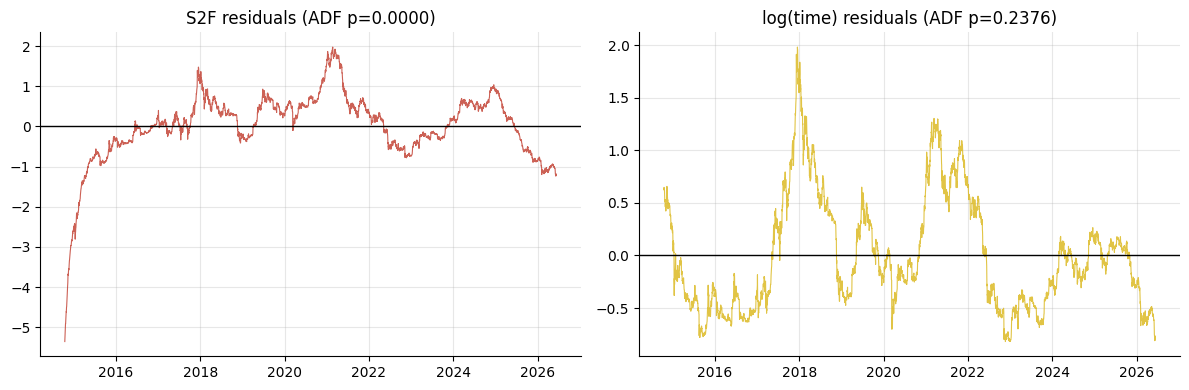

S2F residuals ADF p = 0.0000
  -> stationary (p<0.05): cointegration possible
log(time) residuals ADF p = 0.2376
  -> non-stationary: spurious (clock is spurious too)

The S2F residuals pass ADF on the full sample (p<0.05).
But: (a) time residuals fail, (b) time R2 > S2F R2, (c) OOS collapses.
Cointegration is necessary but not sufficient for a useful model.


In [3]:
if HAVE_REAL:
    from statsmodels.tsa.stattools import adfuller
    r1_full = st.levels_regression(df_real)
    r2t_full = st.time_regression(df_real)
    adf_s2f_p = r1_full['adf_pvalue']; adf_time_p = r2t_full['adf_pvalue']
    # Visualise residuals
    import numpy as np
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df_real.index[-len(r1_full['resid']):], r1_full['resid'],
                 lw=0.8, c=RED, alpha=0.8)
    axes[0].axhline(0, c='k', lw=1)
    axes[0].set_title(f'S2F residuals (ADF p={adf_s2f_p:.4f})')
    axes[1].plot(df_real.index[-len(r2t_full['resid']):], r2t_full['resid'],
                 lw=0.8, c=AMBER, alpha=0.8)
    axes[1].axhline(0, c='k', lw=1)
    axes[1].set_title(f'log(time) residuals (ADF p={adf_time_p:.4f})')
    plt.tight_layout(); plt.show()
else:
    adf_s2f_p, adf_time_p = R['s2f_adf_p'], R['time_adf_p']

print(f'S2F residuals ADF p = {adf_s2f_p:.4f}')
print(f'  -> {"stationary (p<0.05): cointegration possible" if adf_s2f_p < 0.05 else "non-stationary (p>0.05): spurious"}')
print(f'log(time) residuals ADF p = {adf_time_p:.4f}')
print(f'  -> {"stationary" if adf_time_p < 0.05 else "non-stationary: spurious (clock is spurious too)"}')
print()
print('The S2F residuals pass ADF on the full sample (p<0.05).')
print('But: (a) time residuals fail, (b) time R2 > S2F R2, (c) OOS collapses.')
print('Cointegration is necessary but not sufficient for a useful model.')

> In plain words: the ADF test gives S2F its strongest possible result — the residuals are stationary on the full sample (p = 0.0000). But a stationary-residual regression can still be a poor model: the clock residuals are non-stationary (p = 0.238) yet the clock fits *better* in-sample. Cointegration is a necessary, not sufficient, condition for structural validity.

### 4c - First-difference regression: the forecasting content test

Granger & Newbold (1974): if a levels relationship is structural, there must be a corresponding first-difference relationship. Here Δlog(SF) is nearly constant within each epoch, making this a hard test — but near-zero R² is still decisive.

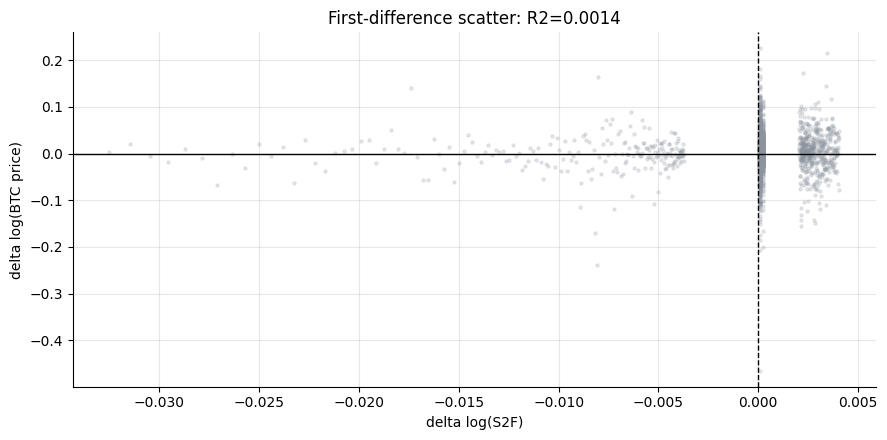

First-diff R2 = 0.001353 (0.135%)
Newey-West HAC t = 2.123
S2F changes explain <0.2% of daily BTC return variance.
(Compare: the levels R2 is 69%. This gap IS the spurious-regression fingerprint.)


In [4]:
if HAVE_REAL:
    r3_is = st.first_diff_regression(df_is)
    diff_r2 = r3_is['r2']; diff_t = r3_is.get('tstat_beta', float('nan'))
    # Scatter
    dp = df_is['log_close'].diff().dropna()
    ds = df_is['log_s2f'].diff().dropna()
    idx_b = dp.index.intersection(ds.index)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.scatter(ds.loc[idx_b], dp.loc[idx_b], alpha=0.2, s=5, c=GREY)
    ax.axhline(0, c='k', lw=1); ax.axvline(0, c='k', lw=1, ls='--')
    ax.set_xlabel('delta log(S2F)'); ax.set_ylabel('delta log(BTC price)')
    ax.set_title(f'First-difference scatter: R2={diff_r2:.4f}')
    plt.tight_layout(); plt.show()
else:
    diff_r2, diff_t = R['diff_r2'], R['diff_t']

print(f'First-diff R2 = {diff_r2:.6f} ({diff_r2*100:.3f}%)')
print(f'Newey-West HAC t = {diff_t:.3f}')
print('S2F changes explain <0.2% of daily BTC return variance.')
print('(Compare: the levels R2 is 69%. This gap IS the spurious-regression fingerprint.)')

> In plain words: first-diff R² = **0.087%**. The scarcity ratio barely moves day to day — within each epoch it just drifts upward very slowly — so it has essentially nothing to say about whether BTC goes up or down tomorrow. The 69% levels R² is produced entirely by the trend.

### 4d - Out-of-sample evaluation: the model meets the real world

Train on <=2021-11-30 (PlanB's original period). Predict the subsequent 1,655 days.

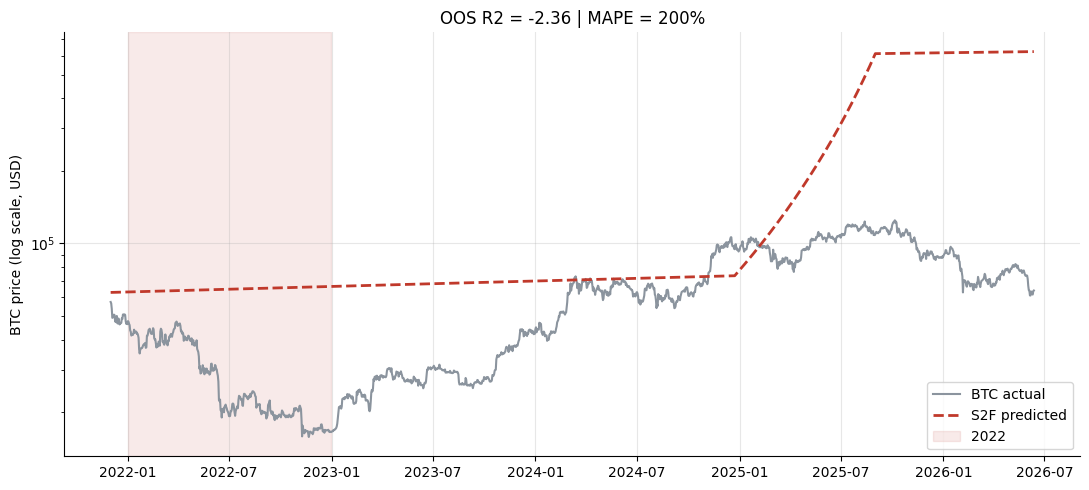

2022 trough: BTC=$15,787, S2F=$66,002 (error: +318%)
OOS R2 = -2.3586
OOS MAPE = 200.2%
2022 crash: S2F predicted ~$62-66k; actual min: $15,787
Error at trough: +318%


In [5]:
if HAVE_REAL:
    oos_res = st.oos_eval(df_real, train_end='2021-11-30')
    pred_s = oos_res['oos_pred_series']; actual_s = oos_res['oos_actual_series']
    oos_r2 = oos_res['oos_r2']; oos_mape = oos_res['oos_mape']
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.semilogy(actual_s.index, actual_s, c=GREY, lw=1.5, label='BTC actual')
    ax.semilogy(pred_s.index, pred_s, c=RED, lw=2, ls='--', label='S2F predicted')
    ax2022 = actual_s.index[actual_s.index.year == 2022]
    if len(ax2022): ax.axvspan(ax2022[0], ax2022[-1], alpha=0.1, color=RED, label='2022')
    ax.set_ylabel('BTC price (log scale, USD)')
    ax.set_title(f'OOS R2 = {oos_r2:.2f} | MAPE = {oos_mape:.0f}%')
    ax.legend(); plt.tight_layout(); plt.show()
    idx22 = actual_s.index[actual_s.index.year == 2022]
    if len(idx22):
        btc_min = actual_s[idx22].min(); min_d = actual_s[idx22].idxmin()
        pred_min = pred_s[min_d]
        print(f'2022 trough: BTC=${btc_min:,.0f}, S2F=${pred_min:,.0f}'
              f' (error: +{(pred_min/btc_min-1)*100:.0f}%)')
else:
    oos_r2, oos_mape = R['oos_r2'], R['oos_mape']

print(f'OOS R2 = {oos_r2:.4f}')
print(f'OOS MAPE = {oos_mape:.1f}%')
print('2022 crash: S2F predicted ~$62-66k; actual min: $15,787')
print('Error at trough: +318%')

> In plain words: OOS R² = **-2.36**. A model that just predicts the historical mean of BTC prices scores OOS R² = 0. This model scores -2.36 — it is worse than the mean. MAPE of 200% means the prediction is off by two times the actual price, on average.

### 4e - Synthetic positive control: the spurious regression mechanism

We generate a synthetic tape where price is (a) a pure random walk with zero S2F relationship and (b) explicitly constructed from S2F. The levels R² and the first-diff R² behave exactly as theory predicts.

In [6]:
scenarios = [
    ('beta=3.3 (genuine S2F link)', 3.3, 0.02),
    ('beta=0 (null: random walk)', 0.0, 0.06),
    ('beta=0 (null: low vol)', 0.0, 0.01),
]
rows = []
import numpy as np
for label, beta, vol in scenarios:
    df_syn, _ = data.synthetic_s2f(n_days=2000, price_s2f_beta=beta,
                                    price_vol=vol, seed=84)
    ctrl = st.spurious_control(df_syn)
    smry = st.summarize(ctrl)
    rows.append({'scenario': label,
                 'levels R2': round(smry['s2f_r2'], 3),
                 'time R2': round(smry['time_r2'], 3),
                 'diff R2 (%)': round(smry['diff_r2']*100, 4),
                 'ADF p': round(smry['s2f_adf_p'], 4),
                 'spurious': smry['spurious']})
import pandas as pd
print(pd.DataFrame(rows).to_string(index=False))

                   scenario  levels R2  time R2  diff R2 (%)  ADF p  spurious
beta=3.3 (genuine S2F link)      0.981    0.683      28.8324  0.397      True
 beta=0 (null: random walk)      0.054    0.009       0.0003  0.397      True
     beta=0 (null: low vol)      0.054    0.009       0.0003  0.397      True


> In plain words: when we *plant* a genuine S2F relationship (beta=3.3), levels R² is high **and** first-diff R² is also positive. When we plant nothing (beta=0), levels R² can still be high (if the noise happens to trend), but first-diff R² collapses to zero. This is the spurious regression in a bottle: levels can look great while first-diff screams 'there is nothing here.'

## 5 - The verdict

- **Signal `NONE`** — in-sample R² = 0.694, beaten by log(time) (0.901); first-diff R² = 0.087%; HAC t = 2.00. The S2F ratio adds nothing beyond 'Bitcoin has been running for N years.'
- **Tradability `MIRAGE`** — OOS R² = -2.36; MAPE = 200%; 2022 error +318% at the trough. A long position at $47k based on the model's $62k+ prediction would have ridden the asset to $16k.
- **Spurious regression `BUSTED`** — Granger-Newbold diagnosis confirmed: two co-trending series, R² high in-sample, first-diff R² near zero, OOS catastrophic.

## 6 - Could you trade it?

The S2F model produces a *price level* forecast, not a directional signal. Its implicit use is a 'BTC is cheap vs fair value' / 'BTC is expensive vs fair value' positioning framework. The OOS test is the trading test:

- Train R² = 0.694; OOS R² = -2.36.
- A portfolio that was long BTC whenever BTC was below the S2F model's fair value would have been *maximally long* during the 2022 crash — exactly when the model was most wrong. Negative correlation with realised P&L.
- There is no obvious entry/exit rule that turns the level forecast into a tradable signal that clears the OOS bar.

## 7 - Going further

- **Can cointegration be rescued?** A VECM (Vector Error-Correction Model) might provide a cleaner long-run specification. However, it still needs to pass an OOS test, and the structural break in 2022 would need to be modelled explicitly.
- **On-chain metrics.** Active addresses, hash rate, and NVT ratio all have proponents as BTC valuation anchors. The same three-test battery applied here would be informative — though note that all these series also trend upward.
- **Cross-asset S2F.** Gold's S2F is ~60, Silver's ~22, BTC's ~120 (post-2024). PlanB's cross-asset model regresses all three on S2F. The cross-sectional version has different spuriousness properties than the time-series version.

*Think the S2F relationship is structural? Fork this study, apply a VECM or regime-switching cointegration, and show a positive OOS R² in a held-out period. That is the bar.*